In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data cleaning process starts


dt = pd.read_csv('IMDB Top 1000 Movies.csv')
# Making a copy of the original dataset.
dt_copy = dt.copy()

In [39]:
print(dt.head())

                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

                         

In [40]:
print(dt.dtypes)

Poster_Link       object
Series_Title      object
Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross             object
dtype: object


In [41]:
# Why is runtime and released year given as objects ?
print(dt.Runtime)
# The column containing the duration has min that can be removed

0      142 min
1      175 min
2      152 min
3      202 min
4       96 min
        ...   
995    115 min
996    201 min
997    118 min
998     97 min
999     86 min
Name: Runtime, Length: 1000, dtype: object


In [42]:
dt_copy['Runtime'] = dt['Runtime'].copy()
print(dt_copy.Runtime)

0      142 min
1      175 min
2      152 min
3      202 min
4       96 min
        ...   
995    115 min
996    201 min
997    118 min
998     97 min
999     86 min
Name: Runtime, Length: 1000, dtype: object


In [43]:
dt_copy['Runtime'] = dt_copy['Runtime'].str.replace(' min', '').astype(int)
print(dt_copy['Runtime'].dtype)
print(dt_copy['Runtime'].describe())

int64
count    1000.000000
mean      122.891000
std        28.093671
min        45.000000
25%       103.000000
50%       119.000000
75%       137.000000
max       321.000000
Name: Runtime, dtype: float64


In [44]:
print(dt_copy['Released_Year'].dtype)
print(dt_copy['Released_Year'].nunique())
print(dt_copy['Released_Year'].value_counts().head(10))

object
100
Released_Year
2014    32
2004    31
2009    29
2013    28
2016    28
2001    27
2006    26
2007    26
2015    25
2012    24
Name: count, dtype: int64


In [45]:
# The column containing the duration has min that can be removedprint(dt['Released_Year'].str.len().value_counts())

#one descrepancy found in the release year.
#lets check if any other kind of descrepancies exist apart from this

In [46]:
suspect_rows = dt_copy[~dt_copy['Released_Year'].str.match(r'^\d{4}$')]
print(suspect_rows[['Series_Title', 'Released_Year']])

# released year mentioned as PG


    Series_Title Released_Year
966    Apollo 13            PG


In [47]:
non_numeric = dt_copy['Released_Year'].apply(lambda x: not str(x).isdigit())
print(f"Non-numeric entries found: {non_numeric.sum()}")

# only one decrepancy exist in the dataset

Non-numeric entries found: 1


In [48]:
dt_copy['Released_Year'] = pd.to_numeric(dt_copy['Released_Year'], errors='coerce')
# coerce gives the value a NaN value if it is not numeric

In [49]:
dt_copy = dt_copy.dropna(subset=['Released_Year'])
dt_copy['Released_Year'] = dt_copy['Released_Year'].astype(int)
# verifying below
print(dt_copy['Released_Year'].dtype)
print(dt_copy['Released_Year'].describe())

int64
count     999.000000
mean     1991.217217
std        23.297025
min      1920.000000
25%      1976.000000
50%      1999.000000
75%      2009.000000
max      2020.000000
Name: Released_Year, dtype: float64


In [50]:
# Gross is also seen as an object due to dollar symbols and commas let make it into an int

print(dt_copy['Gross'].head)
print(dt_copy['Gross'].isna().sum())
print(dt_copy['Gross'].dtypes)

<bound method NDFrame.head of 0       28,341,469
1      134,966,411
2      534,858,444
3       57,300,000
4        4,360,000
          ...     
995            NaN
996            NaN
997     30,500,000
998            NaN
999            NaN
Name: Gross, Length: 999, dtype: object>
169
object


In [51]:
#total 169 missing values in Gross column and replace the commas


dt_copy['Gross'] = pd.to_numeric(dt_copy['Gross'], errors='coerce')

print(dt_copy['Gross'].dtype)
print(dt_copy['Gross'].head())


float64
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Gross, dtype: float64


In [52]:
print(dt_copy.dtypes)
#everything looks clear in the types

Poster_Link       object
Series_Title      object
Released_Year      int64
Certificate       object
Runtime            int64
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross            float64
dtype: object


In [53]:
print("Original shape:", dt.shape)
print("Cleaned shape:", dt_copy.shape)
print(dt_copy.isna().sum())


Original shape: (1000, 16)
Cleaned shape: (999, 16)
Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            999
dtype: int64


In [55]:
# dropping such huge numbers of data in any of the missing values dont make sense
#lets visualize now

In [58]:
sns.set_style("whitegrid")
%matplotlib inline

In [60]:
print(f"Lowest rating: {dt_copy['IMDB_Rating'].min()}")
print(f"Highest rating: {dt_copy['IMDB_Rating'].max()}")
print(f"Average rating: {dt_copy['IMDB_Rating'].mean():.2f}")
print(f"Median rating: {dt_copy['IMDB_Rating'].median()}")

Lowest rating: 7.6
Highest rating: 9.3
Average rating: 7.95
Median rating: 7.9


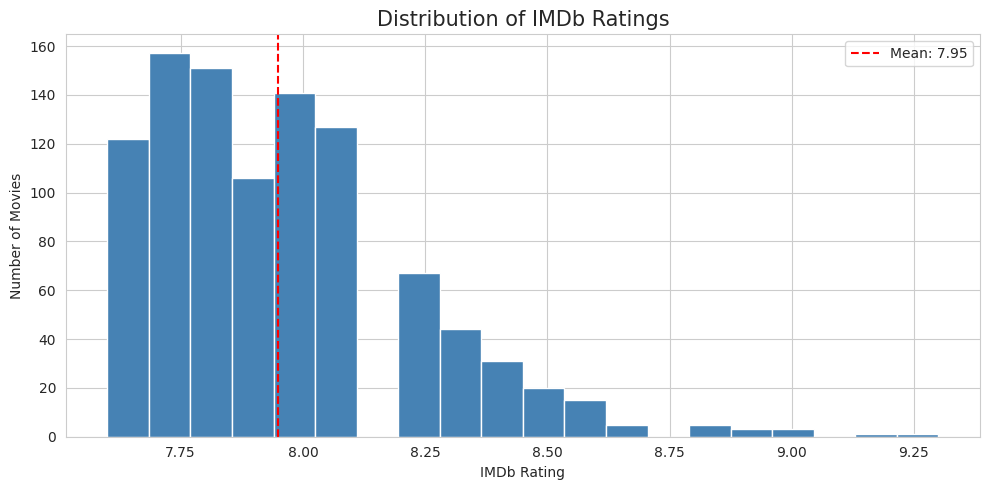

In [62]:
plt.figure(figsize=(10, 5))

plt.hist(dt_copy['IMDB_Rating'], bins=20, color='steelblue', edgecolor='white')

plt.title('Distribution of IMDb Ratings', fontsize=15)
plt.xlabel('IMDb Rating')
plt.ylabel('Number of Movies')

plt.axvline(dt_copy['IMDB_Rating'].mean(), color='red',
            linestyle='--', label=f"Mean: {dt_copy['IMDB_Rating'].mean():.2f}")

plt.legend()
plt.tight_layout()
plt.show()


The distribution of IMDb ratings is left-skewed with most movies
between 7.6 and 8.5
This is expected since the dataset
represents the top 1000 rated films on imdb.
The mean rating of 7.95 suggests a most of the movies are considered really good in real world

In [63]:
# lets move to genre

print(dt_copy['Genre'].head())

#Here the genres in all the movies are considered as one entity.. we need to split them

0                   Drama
1            Crime, Drama
2    Action, Crime, Drama
3            Crime, Drama
4            Crime, Drama
Name: Genre, dtype: object


In [67]:
# splitting and flattening into one big list
all_genres = dt_copy['Genre'].str.split(', ').explode()

print(all_genres.head(15))
print(len(all_genres))
print(all_genres.nunique())

0        Drama
1        Crime
1        Drama
2       Action
2        Crime
2        Drama
3        Crime
3        Drama
4        Crime
4        Drama
5       Action
5    Adventure
5        Drama
6        Crime
6        Drama
Name: Genre, dtype: object
2538
21


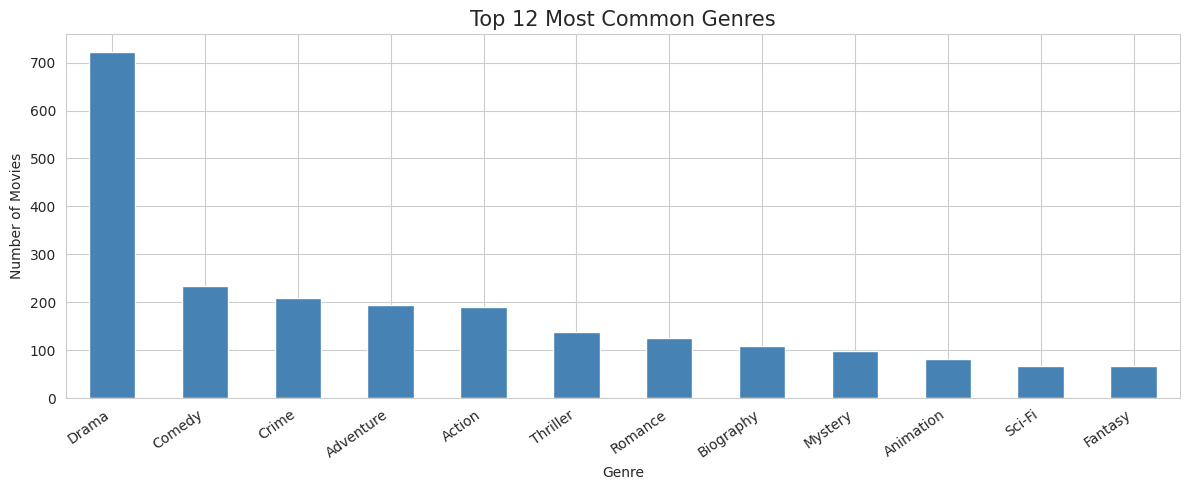

Genre
Drama        723
Comedy       233
Crime        209
Adventure    195
Action       189
Thriller     137
Romance      125
Biography    109
Mystery       99
Animation     82
Sci-Fi        67
Fantasy       66
Name: count, dtype: int64


In [68]:
genre_counts = all_genres.value_counts().head(12)

plt.figure(figsize=(12, 5))

genre_counts.plot(kind='bar', color='steelblue', edgecolor='white')

plt.title('Top 12 Most Common Genres', fontsize=15)
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print(genre_counts)

Drama is overwhelmingly the most common genre in the imdb top 1000,
appearing in over  723 movies
Comedy and Crime follow as the second and
third most frequent genres. This suggests that critically acclaimed
and highly voted films tend to favour character-driven narratives
over pure action or spectacle. Many movies carry multiple genre tags,
meaning genres like Drama often appear alongside others like Crime
or Romance rather than standalone.

In [70]:
avg_genres = dt_copy['Genre'].str.split(', ').apply(len).mean()
print(avg_genres)

2.5405405405405403


In [71]:
#Lets convert the released year to decade to make things easier by deriving it from released year

# 1994 // 10 = 199, then 199 * 10 = 1990
dt_copy['Decade'] = (dt_copy['Released_Year'] // 10 * 10).astype(str) + 's'

print(dt_copy[['Released_Year', 'Decade']].head(10))

   Released_Year Decade
0           1994  1990s
1           1972  1970s
2           2008  2000s
3           1974  1970s
4           1957  1950s
5           2003  2000s
6           1994  1990s
7           1993  1990s
8           2010  2010s
9           1999  1990s


In [72]:
decade_counts = dt_copy.groupby('Decade')['Series_Title'].count().reset_index()
decade_counts.columns = ['Decade', 'Movie_Count']
print(decade_counts)

   Decade  Movie_Count
0   1920s           11
1   1930s           24
2   1940s           35
3   1950s           56
4   1960s           73
5   1970s           76
6   1980s           89
7   1990s          150
8   2000s          237
9   2010s          242
10  2020s            6


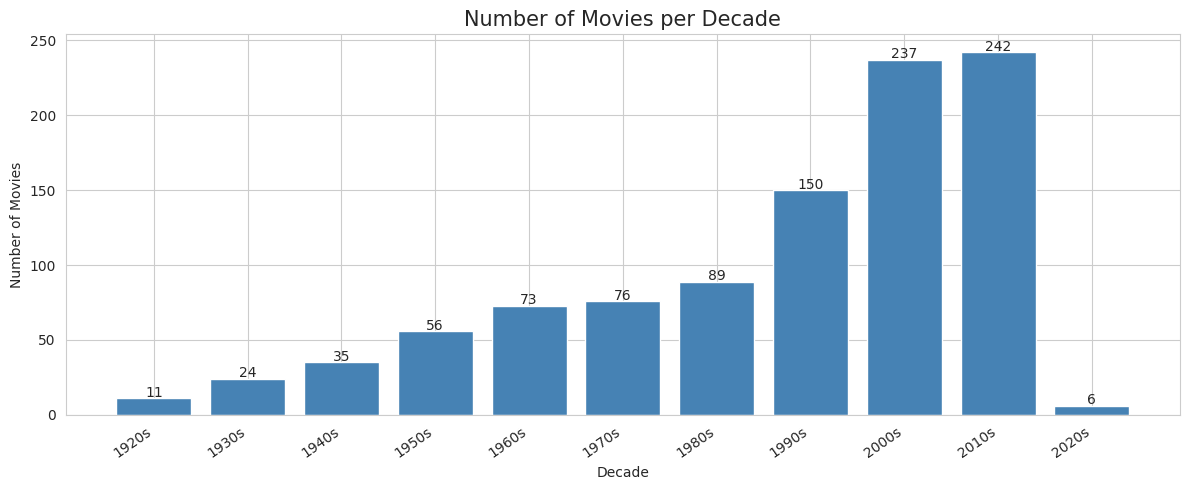

In [73]:
plt.figure(figsize=(12, 5))

plt.bar(decade_counts['Decade'], decade_counts['Movie_Count'],
        color='steelblue', edgecolor='white')

plt.title('Number of Movies per Decade', fontsize=15)
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.xticks(rotation=35, ha='right')

for i, row in decade_counts.iterrows():
    plt.text(i, row['Movie_Count'] + 1, str(row['Movie_Count']),
             ha='center', fontsize=10)

plt.tight_layout()
plt.show()

The distribution of movies across decades is right-skewed, with the
number of films increasing significantly from the 1990s onwards,
peaking in the 2010s with 242 movies.

However, this trend may not purely reflect film quality. A key
limitation of this dataset is potential recency bias — IMDb ratings
are driven by user votes, and the internet boom of the 2000s and 2010s
means younger, more internet-savvy generations are disproportionately
represented in the voting base. Classic films from the 1940s-1960s
may be underrepresented simply because fewer people from that era
are actively voting online, not because the films are less deserving.

This is an important caveat to keep in mind when interpreting any
decade-based analysis in this dataset.

In [74]:
# finding the unique directors
print(f"Total unique directors: {dt_copy['Director'].nunique()}")

# most appeared
print(dt_copy['Director'].value_counts().head(10))

Total unique directors: 548
Director
Alfred Hitchcock     14
Steven Spielberg     13
Hayao Miyazaki       11
Akira Kurosawa       10
Martin Scorsese      10
Woody Allen           9
Stanley Kubrick       9
Billy Wilder          9
Clint Eastwood        8
Christopher Nolan     8
Name: count, dtype: int64


Alfred Hitchcock leads with the most movies in the IMDb Top 1000,
followed by Steven Spielberg and Hayao Miyazaki.

This is particularly noteworthy because Hitchcock's dominance
reinforces our earlier bias observation — his films are from the
1950s and 1960s, yet they still rank among the most acclaimed.
This suggests that truly exceptional filmmaking transcends
generational voting bias.

Miyazaki's presence is remarkable as he represents non-English
language cinema, showing that IMDb's Top 1000 is not purely
dominated by Hollywood productions. Spielberg bridges both
classic and modern cinema, with films spanning from the 1970s
all the way to the 2000s.

In [75]:
# how are runtime and rating are related?


print(f"Shortest movie: {dt_copy['Runtime'].min()} mins")
print(f"Longest movie: {dt_copy['Runtime'].max()} mins")
print(f"Average runtime: {dt_copy['Runtime'].mean():.2f} mins")

print(dt_copy[dt_copy['Runtime'] == dt_copy['Runtime'].min()][['Series_Title', 'Runtime']])
print(dt_copy[dt_copy['Runtime'] == dt_copy['Runtime'].max()][['Series_Title', 'Runtime']])

Shortest movie: 45 mins
Longest movie: 321 mins
Average runtime: 122.87 mins
     Series_Title  Runtime
194  Sherlock Jr.       45
           Series_Title  Runtime
140  Gangs of Wasseypur      321


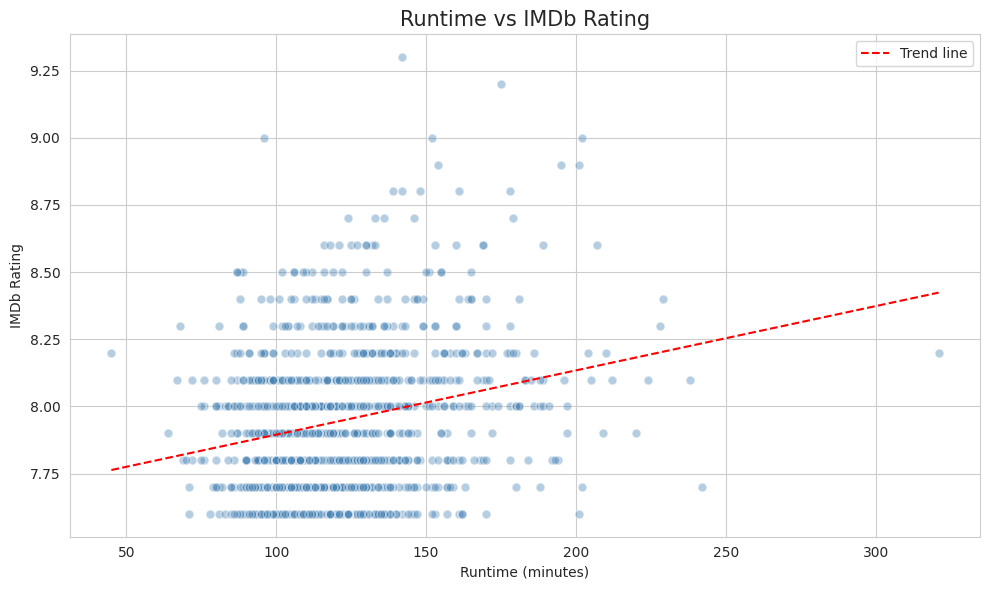

In [76]:
plt.figure(figsize=(10, 6))

plt.scatter(dt_copy['Runtime'], dt_copy['IMDB_Rating'],
            alpha=0.4, color='steelblue', edgecolor='white', s=40)

plt.title('Runtime vs IMDb Rating', fontsize=15)
plt.xlabel('Runtime (minutes)')
plt.ylabel('IMDb Rating')

z = np.polyfit(dt_copy['Runtime'], dt_copy['IMDB_Rating'], 1)
p = np.poly1d(z)
plt.plot(sorted(dt_copy['Runtime']), p(sorted(dt_copy['Runtime'])),
         color='red', linestyle='--', label='Trend line')

plt.legend()
plt.tight_layout()
plt.show()

In [77]:
correlation = dt_copy['Runtime'].corr(dt_copy['IMDB_Rating'])
print(f"Correlation between Runtime and Rating: {correlation:.2f}")

Correlation between Runtime and Rating: 0.24


The scatter plot reveals a weak positive correlation (r = 0.24) between
runtime and IMDb rating. While the trend line shows a slight upward slope,
the wide spread of points indicates runtime alone is a poor predictor
of a movie's rating.

Interestingly, the shortest movie is Sherlock Jr. (1924), a silent era
film, while the longest is Gangs of Wasseypur — a Bollywood epic. Both
representing non-Hollywood cinema performing strongly on IMDb, further
challenging the assumption that the platform is purely Western-dominated.

The weak correlation suggests that audiences value storytelling quality
and emotional impact over film length.

In [78]:
print(f"Least voted movie: {dt_copy['No_of_Votes'].min():,}")
print(f"Most voted movie: {dt_copy['No_of_Votes'].max():,}")
print(f"Average votes: {dt_copy['No_of_Votes'].mean():,.0f}")

# Find the actual movies
print(dt_copy[dt_copy['No_of_Votes'] == dt_copy['No_of_Votes'].max()][['Series_Title','No_of_Votes','IMDB_Rating']])
print(dt_copy[dt_copy['No_of_Votes'] == dt_copy['No_of_Votes'].min()][['Series_Title','No_of_Votes','IMDB_Rating']])

Least voted movie: 25,088
Most voted movie: 2,343,110
Average votes: 273,697
               Series_Title  No_of_Votes  IMDB_Rating
0  The Shawshank Redemption      2343110          9.3
       Series_Title  No_of_Votes  IMDB_Rating
264  Ba wang bie ji        25088          8.1


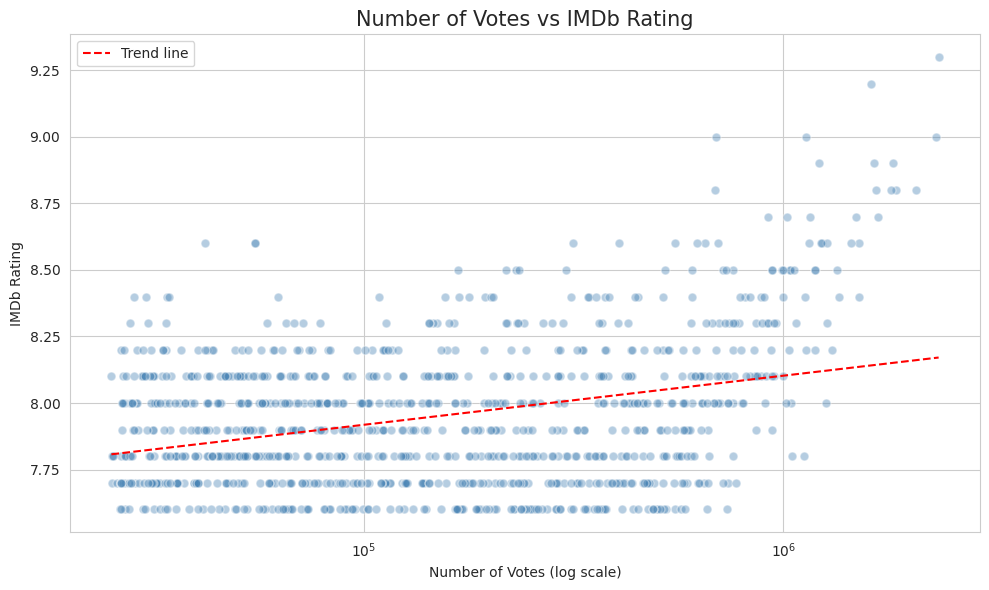

Correlation between Votes and Rating: 0.50


In [79]:
plt.figure(figsize=(10, 6))

plt.scatter(dt_copy['No_of_Votes'], dt_copy['IMDB_Rating'],
            alpha=0.4, color='steelblue', edgecolor='white', s=40)

plt.xscale('log')

plt.title('Number of Votes vs IMDb Rating', fontsize=15)
plt.xlabel('Number of Votes (log scale)')
plt.ylabel('IMDb Rating')

log_votes = np.log10(dt_copy['No_of_Votes'])
z = np.polyfit(log_votes, dt_copy['IMDB_Rating'], 1)
p = np.poly1d(z)
x_sorted = sorted(dt_copy['No_of_Votes'])
plt.plot(x_sorted, p(np.log10(x_sorted)),
         color='red', linestyle='--', label='Trend line')

plt.legend()
plt.tight_layout()
plt.show()

correlation = dt_copy['No_of_Votes'].corr(dt_copy['IMDB_Rating'])
print(f"Correlation between Votes and Rating: {correlation:.2f}")

The scatter plot of Number of Votes vs IMDb Rating reveals a moderate
positive correlation (r = 0.50), stronger than the Runtime correlation
(r = 0.24). This suggests that popularity and quality are more closely
linked than runtime and quality — films that attract larger audiences
tend to be rated higher.

The Shawshank Redemption leads with the most votes, consistent with
its long standing position at the top of IMDb rankings. Ba Wang Bie Ji
(Farewell My Concubine) has the fewest votes despite being a critically
acclaimed Chinese historical drama — likely reflecting the language and
regional bias in IMDb's predominantly English speaking voter base.

A log scale was applied to the x axis due to the extreme range of vote
counts (25,000 to 2,300,000), which would have compressed most data
points into an unreadable cluster on a linear scale.

In [83]:
# moving into the TF-IDF, we need to combine all the text fields

# Combine all relevant text columns into one
dt_copy['Combined_Text'] = (
    dt_copy['Series_Title'] + ' ' +
    dt_copy['Genre'] + ' ' +
    dt_copy['Director'] + ' ' +
    dt_copy['Star1'] + ' ' +
    dt_copy['Star2'] + ' ' +
    dt_copy['Star3'] + ' ' +
    dt_copy['Star4'] + ' ' +
    dt_copy['Overview']
)

print(dt_copy['Combined_Text'][0])

The Shawshank Redemption Drama Frank Darabont Tim Robbins Morgan Freeman Bob Gunton William Sadler Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.


In [84]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    sublinear_tf=True,
    stop_words='english'
)

tfidf_matrix = vectorizer.fit_transform(dt_copy['Combined_Text'])

print(f"Matrix shape: {tfidf_matrix.shape}")
print(f"Each movie is represented by {tfidf_matrix.shape[1]} features")

Matrix shape: (999, 5000)
Each movie is represented by 5000 features


In [85]:
#checking sparsity
sparsity = 1 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))
print(f"Matrix sparsity: {sparsity:.2%}")

Matrix sparsity: 99.47%


The TF-IDF matrix has a shape of (999, 5000), where each of the 999
movies is represented as a vector of 5000 numerical features. The
matrix sparsity of 99.47% indicates that most words only appear in
a small subset of movies, which is expected and desirable — it means
each movie has a unique fingerprint of meaningful words rather than
sharing common vocabulary across the entire dataset.

The Combined_Text field was constructed by concatenating the movie
title, genre, director, cast, and plot overview — giving the vectorizer
rich contextual information to work with. Stop words were removed and
bigrams were included to capture meaningful phrases like "serial killer"
or "based on true story".

In [90]:
def search_movies(query, top_k=5, year_min=None, year_max=None,
                  min_rating=None, max_runtime=None, genre_filter=None):

    # Convert query to vector and get similarity scores
    query_vector = vectorizer.transform([query])
    similarity_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Start with all movies
    filtered_df = dt_copy.copy()
    filtered_df['Similarity_Score'] = similarity_scores

    # Apply filters if provided
    if year_min:
        filtered_df = filtered_df[filtered_df['Released_Year'] >= year_min]
    if year_max:
        filtered_df = filtered_df[filtered_df['Released_Year'] <= year_max]
    if min_rating:
        filtered_df = filtered_df[filtered_df['IMDB_Rating'] >= min_rating]
    if max_runtime:
        filtered_df = filtered_df[filtered_df['Runtime'] <= max_runtime]
    if genre_filter:
        filtered_df = filtered_df[filtered_df['Genre'].str.contains(genre_filter, case=False, na=False)]

    # Sort by similarity and return top_k
    results = filtered_df.sort_values('Similarity_Score', ascending=False).head(top_k)

    return results[['Series_Title', 'Genre', 'Director',
                    'IMDB_Rating', 'Released_Year', 'Similarity_Score']]

In [91]:
# Movies after 2000 with rating above 8.5
print("Sci-fi movies after 2000:")
print(search_movies('sci-fi space', year_min=2000, genre_filter='Sci-Fi'))
print()

# Short comedy movies
print("Short comedy movies:")
print(search_movies('comedy funny', max_runtime=100, genre_filter='Comedy'))
print()

# Highly rated crime movies
print("Highly rated crime movies:")
print(search_movies('crime gangster', min_rating=8.5, genre_filter='Crime'))

Sci-fi movies after 2000:
                              Series_Title                      Genre  \
745                                Gravity    Drama, Sci-Fi, Thriller   
21                            Interstellar   Adventure, Drama, Sci-Fi   
366                               G.O.R.A.  Adventure, Comedy, Sci-Fi   
94   Eternal Sunshine of the Spotless Mind     Drama, Romance, Sci-Fi   
488                             District 9   Action, Sci-Fi, Thriller   

              Director  IMDB_Rating  Released_Year  Similarity_Score  
745     Alfonso Cuarón          7.7           2013          0.299504  
21   Christopher Nolan          8.6           2014          0.286537  
366   Ömer Faruk Sorak          8.0           2004          0.208711  
94       Michel Gondry          8.3           2004          0.192985  
488     Neill Blomkamp          7.9           2009          0.190669  

Short comedy movies:
             Series_Title                   Genre         Director  \
972          Deli

In [93]:
# lets work on the intent parser now as the RAG pipeline should be

import re

def parse_intent(text):
    """
    Extracts filters from natural language query.
    Returns a dictionary of filters.
    """
    text_lower = text.lower()
    filters = {}

    # Extract year filters
    # Looks for patterns like "after 2000", "before 1990", "in 1994"
    after_match = re.search(r'after\s+(\d{4})', text_lower)
    before_match = re.search(r'before\s+(\d{4})', text_lower)
    in_match = re.search(r'in\s+(\d{4})', text_lower)

    if after_match:
        filters['year_min'] = int(after_match.group(1))
    if before_match:
        filters['year_max'] = int(before_match.group(1))
    if in_match:
        filters['year_min'] = int(in_match.group(1))
        filters['year_max'] = int(in_match.group(1))

    # Extract decade filter
    # Looks for patterns like "1990s", "2000s"
    decade_match = re.search(r'(\d{4})s', text_lower)
    if decade_match:
        decade = int(decade_match.group(1))
        filters['year_min'] = decade
        filters['year_max'] = decade + 9

    # Extract rating filters
    if any(word in text_lower for word in ['highly rated', 'top rated', 'best']):
        filters['min_rating'] = 8.5
    elif 'good' in text_lower:
        filters['min_rating'] = 7.5

    rating_match = re.search(r'rating\s*(above|over|greater than)\s*(\d+\.?\d*)', text_lower)
    if rating_match:
        filters['min_rating'] = float(rating_match.group(2))

    # Extract runtime filter
    # Looks for "under 2 hours", "less than 120 minutes"
    hours_match = re.search(r'under\s+(\d+)\s+hour', text_lower)
    mins_match = re.search(r'less than\s+(\d+)\s+min', text_lower)

    if hours_match:
        filters['max_runtime'] = int(hours_match.group(1)) * 60
    if mins_match:
        filters['max_runtime'] = int(mins_match.group(1))

    # Extract genre filter
    genres = ['action', 'comedy', 'drama', 'crime', 'thriller',
              'romance', 'horror', 'adventure', 'animation',
              'sci-fi', 'fantasy', 'mystery', 'biography', 'history']
    for genre in genres:
        if genre in text_lower:
            filters['genre_filter'] = genre.title()
            break

    return filters

In [94]:
test_queries = [
    "suggest crime movies after 2000",
    "best comedy movies from the 1990s",
    "thriller movies with rating above 8",
    "action movies under 2 hours",
    "highly rated drama movies before 1980",
]

for query in test_queries:
    print(f"Query  : '{query}'")
    print(f"Filters: {parse_intent(query)}")
    print()

Query  : 'suggest crime movies after 2000'
Filters: {'year_min': 2000, 'genre_filter': 'Crime'}

Query  : 'best comedy movies from the 1990s'
Filters: {'year_min': 1990, 'year_max': 1999, 'min_rating': 8.5, 'genre_filter': 'Comedy'}

Query  : 'thriller movies with rating above 8'
Filters: {'min_rating': 8.0, 'genre_filter': 'Thriller'}

Query  : 'action movies under 2 hours'
Filters: {'max_runtime': 120, 'genre_filter': 'Action'}

Query  : 'highly rated drama movies before 1980'
Filters: {'year_max': 1980, 'min_rating': 8.5, 'genre_filter': 'Drama'}



In [95]:
def generate_response(query, results):
    """
    Takes search results and formats a conversational response.
    """
    if results.empty:
        return "I couldn't find any movies matching your query. Could you try rephrasing or using different keywords?"

    response = f"Here are some movies matching '{query}':\n\n"

    for i, (_, row) in enumerate(results.iterrows(), 1):
        response += f"{i}. {row['Series_Title']} ({row['Released_Year']})\n"
        response += f"   Genre: {row['Genre']}\n"
        response += f"   Director: {row['Director']}\n"
        response += f"   IMDb Rating: {row['IMDB_Rating']}\n"
        response += f"   Match Score: {row['Similarity_Score']:.3f}\n\n"

    return response

In [107]:
class MovieChatBot:
    """
    Conversational movie chatbot using RAG pipeline.
    Maintains conversation history for multi-turn interactions.
    """

    def __init__(self):
        self.conversation_history = []
        self.last_results = None

    def chat(self, user_input):
        # Store user message in history
        self.conversation_history.append({
            'role': 'user',
            'message': user_input
        })

        user_lower = user_input.lower()

        # Handle greetings
        if any(word in user_lower for word in ['hello', 'hi', 'hey']):
            response = ("Hello! I'm MovieMate, your personal movie guide. "
                       "Ask me anything! For example:\n"
                       "- 'Suggest thriller movies after 2000'\n"
                       "- 'Best comedy movies from the 1990s'\n"
                       "- 'Movies directed by Christopher Nolan'\n"
                       "- 'Action movies with rating above 8.5'")

        # ↓ THIS IS WHERE THE FIX GOES — replaces the old elif block
        elif any(word in user_lower for word in ['more', 'other', 'different', 'else']):
            if self.last_results is not None:
                last_query = None
                for entry in reversed(self.conversation_history):
                    if entry['role'] == 'user' and not any(
                        word in entry['message'].lower()
                        for word in ['more', 'other', 'different', 'else', 'hello', 'hi', 'thanks']):
                        last_query = entry['message']
                        break

                if last_query:
                    filters = parse_intent(last_query)
                    results = search_movies(last_query, top_k=10, **filters)
                    results = results.iloc[5:]
                    self.last_results = results
                    response = generate_response(last_query, results)
                else:
                    response = "Could you tell me what kind of movies you're looking for first?"
            else:
                response = "Could you tell me what kind of movies you're looking for first?"

        # Handle thank you
        elif any(word in user_lower for word in ['thank', 'thanks', 'great', 'awesome']):
            response = "You're welcome! Enjoy your movie! Let me know if you need more recommendations."

        # Handle help
        elif 'help' in user_lower:
            response = ("Here's what you can ask me:\n"
                       "- Genre: 'suggest horror movies'\n"
                       "- Director: 'movies by Steven Spielberg'\n"
                       "- Year: 'crime movies after 2000'\n"
                       "- Rating: 'highly rated drama movies'\n"
                       "- Runtime: 'comedy movies under 2 hours'\n"
                       "- Combined: 'best thriller movies from the 1990s'")

        # Main movie search
        else:
            filters = parse_intent(user_input)
            results = search_movies(user_input, top_k=5, **filters)
            self.last_results = results
            response = generate_response(user_input, results)

        # Store bot response in history
        self.conversation_history.append({
            'role': 'bot',
            'message': response
        })

        return response

    def show_history(self):
        """Prints the full conversation history."""
        for entry in self.conversation_history:
            role = "You" if entry['role'] == 'user' else "Bot"
            print(f"{role}: {entry['message']}")
            print("-" * 50)

In [97]:

bot = MovieChatBot()


print(bot.chat("Hello!"))
print()
print(bot.chat("Suggest some thriller movies after 2000"))
print()
print(bot.chat("Can you show me more?"))
print()
print(bot.chat("What about highly rated crime movies from the 1990s?"))
print()
print(bot.chat("Movies directed by Christopher Nolan"))
print()
print(bot.chat("Thanks!"))

Hello! I'm MovieMate, your personal movie guide. Ask me anything! For example:
- 'Suggest thriller movies after 2000'
- 'Best comedy movies from the 1990s'
- 'Movies directed by Christopher Nolan'
- 'Action movies with rating above 8.5'

Here are some movies matching 'Suggest some thriller movies after 2000':

1. Drishyam (2013)
   Genre: Crime, Drama, Thriller
   Director: Jeethu Joseph
   IMDb Rating: 8.3
   Match Score: 0.079

2. Nefes: Vatan Sagolsun (2009)
   Genre: Action, Drama, Thriller
   Director: Levent Semerci
   IMDb Rating: 8.0
   Match Score: 0.077

3. Kokuhaku (2010)
   Genre: Drama, Thriller
   Director: Tetsuya Nakashima
   IMDb Rating: 7.8
   Match Score: 0.076

4. Nueve reinas (2000)
   Genre: Crime, Drama, Thriller
   Director: Fabián Bielinsky
   IMDb Rating: 7.9
   Match Score: 0.066

5. Relatos salvajes (2014)
   Genre: Comedy, Drama, Thriller
   Director: Damián Szifron
   IMDb Rating: 8.1
   Match Score: 0.063



Here are some movies matching 'Here are some mo

In [108]:

bot = MovieChatBot()

print(bot.chat("Suggest some thriller movies after 2000"))
print()
print(bot.chat("Can you show me more?"))

Here are some movies matching 'Suggest some thriller movies after 2000':

1. Drishyam (2013)
   Genre: Crime, Drama, Thriller
   Director: Jeethu Joseph
   IMDb Rating: 8.3
   Match Score: 0.079

2. Nefes: Vatan Sagolsun (2009)
   Genre: Action, Drama, Thriller
   Director: Levent Semerci
   IMDb Rating: 8.0
   Match Score: 0.077

3. Kokuhaku (2010)
   Genre: Drama, Thriller
   Director: Tetsuya Nakashima
   IMDb Rating: 7.8
   Match Score: 0.076

4. Nueve reinas (2000)
   Genre: Crime, Drama, Thriller
   Director: Fabián Bielinsky
   IMDb Rating: 7.9
   Match Score: 0.066

5. Relatos salvajes (2014)
   Genre: Comedy, Drama, Thriller
   Director: Damián Szifron
   IMDb Rating: 8.1
   Match Score: 0.063



Here are some movies matching 'Suggest some thriller movies after 2000':

1. Searching (2018)
   Genre: Drama, Mystery, Thriller
   Director: Aneesh Chaganty
   IMDb Rating: 7.6
   Match Score: 0.056

2. The Machinist (2004)
   Genre: Drama, Thriller
   Director: Brad Anderson
   IMDb

In [110]:
!pip install gradio

In [111]:
import gradio as gr

# Fresh bot instance
gradio_bot = MovieChatBot()

def chat_with_bot(user_message, history):
    """
    This function is called every time the user sends a message.
    history — Gradio automatically maintains this as a list of
    [user_message, bot_response] pairs
    """
    response = gradio_bot.chat(user_message)
    history.append([user_message, response])
    return "", history

# Build the interface
with gr.Blocks(title="MovieMate") as demo:

    gr.Markdown("""
    # 🎬 MovieMate
    **Your personal IMDb movie recommendation assistant**

    Try asking:
    - *"Suggest thriller movies after 2000"*
    - *"Best comedy movies from the 1990s"*
    - *"Movies directed by Christopher Nolan"*
    - *"Highly rated crime movies"*
    - *"Action movies under 2 hours"*
    """)

    chatbot = gr.Chatbot(
        height=450,
        label="MovieMate Chat"
    )

    with gr.Row():
        input_box = gr.Textbox(
            placeholder="Ask me about movies...",
            label="Your message",
            scale=8
        )
        send_btn = gr.Button("Send 🎬", scale=1, variant="primary")

    clear_btn = gr.Button("Clear Chat")

    # Connectiing components
    send_btn.click(
        fn=chat_with_bot,
        inputs=[input_box, chatbot],
        outputs=[input_box, chatbot]
    )

    input_box.submit(
        fn=chat_with_bot,
        inputs=[input_box, chatbot],
        outputs=[input_box, chatbot]
    )

    clear_btn.click(
        fn=lambda: ([], ""),
        outputs=[chatbot, input_box]
    )

# Launch
demo.launch(share=True, debug=True)

/tmp/ipykernel_18226/3068492656.py:31: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(
/tmp/ipykernel_18226/3068492656.py:31: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d21449e2529c4a884d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://d21449e2529c4a884d.gradio.live
